<a href="https://colab.research.google.com/github/Buckethead1472/Challenge-Alura-TelecomX-ML/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Pandas/datos_tratados.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7043 non-null   object 
 1   dejo_empresa          7043 non-null   int64  
 2   genero                7043 non-null   object 
 3   tercera_edad          7043 non-null   int64  
 4   pareja                7043 non-null   int64  
 5   dependientes          7043 non-null   int64  
 6   contrato_meses        7043 non-null   int64  
 7   subs_telefono         7043 non-null   int64  
 8   sub_mas_lineas        7043 non-null   object 
 9   sub_internet          7043 non-null   object 
 10  sub_seguridad         7043 non-null   object 
 11  sub_respaldo          7043 non-null   object 
 12  proteccion_adicional  7043 non-null   object 
 13  soporte_tecnico       7043 non-null   object 
 14  sub_streamingTV       7043 non-null   object 
 15  sub_streamingMovies  

In [4]:
df = df.drop(columns=['ID_Cliente'])

In [5]:
columnas_categoricas = df.select_dtypes(include=['object']).columns

In [6]:
encoder = OneHotEncoder(sparse_output=False, drop='if_binary')

In [7]:
datos_codificados = encoder.fit_transform(df[columnas_categoricas])

In [8]:
df_codificado = pd.DataFrame(
    datos_codificados,
    columns=encoder.get_feature_names_out(columnas_categoricas)
)

In [9]:
df_final = pd.concat([df.drop(columnas_categoricas, axis=1), df_codificado], axis=1)

In [10]:
conteo_absoluto = df['dejo_empresa'].value_counts()
conteo_relativo = df['dejo_empresa'].value_counts(normalize=True) * 100

/tmp/ipykernel_220/2998626109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='dejo_empresa', data=df, palette='magma')


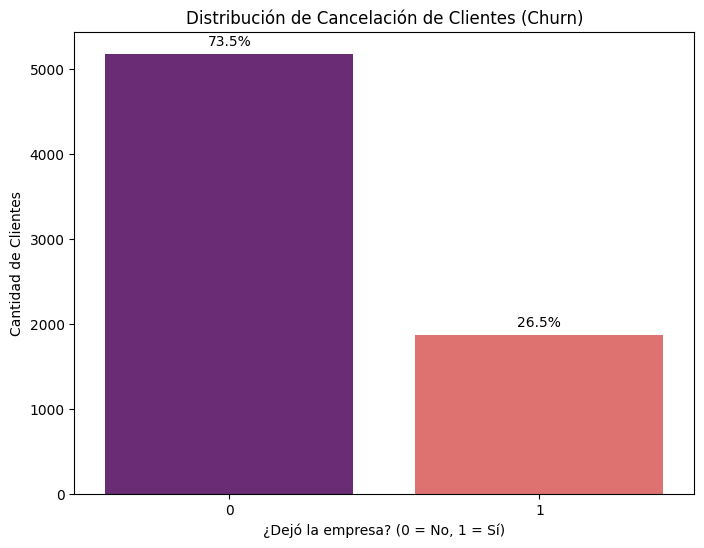

In [11]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='dejo_empresa', data=df, palette='magma')

for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df):.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribución de Cancelación de Clientes (Churn)')
plt.xlabel('¿Dejó la empresa? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [12]:
X = df_final.drop('dejo_empresa', axis=1)
y = df_final['dejo_empresa']

In [13]:
smt = SMOTE(random_state=42)

--- ANTES DEL BALANCEO ---
dejo_empresa
0    5174
1    1869
Name: count, dtype: int64

--- DESPUÉS DEL BALANCEO (SMOTE) ---
dejo_empresa
0    5174
1    5174
Name: count, dtype: int64


/tmp/ipykernel_220/4173071053.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res, palette='viridis')


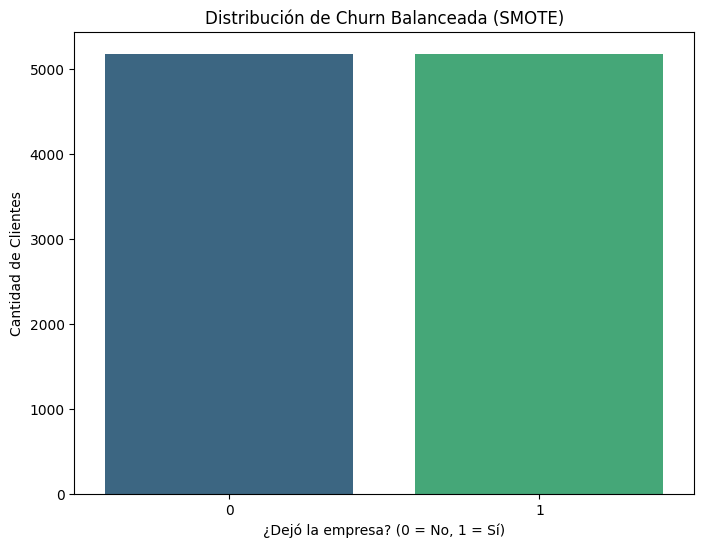

In [14]:
X_res, y_res = smt.fit_resample(X, y)

print("--- ANTES DEL BALANCEO ---")
print(y.value_counts())

print("\n--- DESPUÉS DEL BALANCEO (SMOTE) ---")
print(y_res.value_counts())

# 5. Visualización del cambio
plt.figure(figsize=(8, 6))
sns.countplot(x=y_res, palette='viridis')
plt.title('Distribución de Churn Balanceada (SMOTE)')
plt.xlabel('¿Dejó la empresa? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [24]:
num_cols = ['contrato_meses', 'facturacion_mensual', 'facturacion_total', 'facturacion_diario']
scaler = StandardScaler()
scaler = StandardScaler()
X_res[num_cols] = scaler.fit_transform(X_res[num_cols])
display(X_res[num_cols].head())

,contrato_meses,facturacion_mensual,facturacion_total,facturacion_diario
0,-0.777785,-0.084491,-0.664634,-0.081002
1,-0.777785,-0.282965,-0.687909,-0.279455
2,-0.986243,0.204516,-0.807504,0.201010
3,-0.611017,1.043680,-0.369909,1.047046
4,-1.027935,0.552717,-0.813654,0.556136


In [16]:
X_original = df_final.drop('dejo_empresa', axis=1)
y_original = df_final['dejo_empresa']

In [17]:
smt_tecnico = SMOTE(random_state=42)
X_balanceado, y_balanceado = smt_tecnico.fit_resample(X_original, y_original)

In [18]:
print("--- Conteo después de SMOTE ---")
print(y_balanceado.value_counts())

--- Conteo después de SMOTE ---
dejo_empresa
0    5174
1    5174
Name: count, dtype: int64


In [25]:
columnas_numericas = ['contrato_meses', 'facturacion_mensual', 'facturacion_total']

X_final_escalado = X_balanceado.copy()

escalador_telecom = StandardScaler()
X_final_escalado[columnas_numericas] = escalador_telecom.fit_transform(X_balanceado[columnas_numericas])

print("--- Datos escalados listos para el modelo ---")
display(X_final_escalado[columnas_numericas].head())

--- Datos escalados listos para el modelo ---


,contrato_meses,facturacion_mensual,facturacion_total
0,-0.777785,-0.084491,-0.664634
1,-0.777785,-0.282965,-0.687909
2,-0.986243,0.204516,-0.807504
3,-0.611017,1.043680,-0.369909
4,-1.027935,0.552717,-0.813654


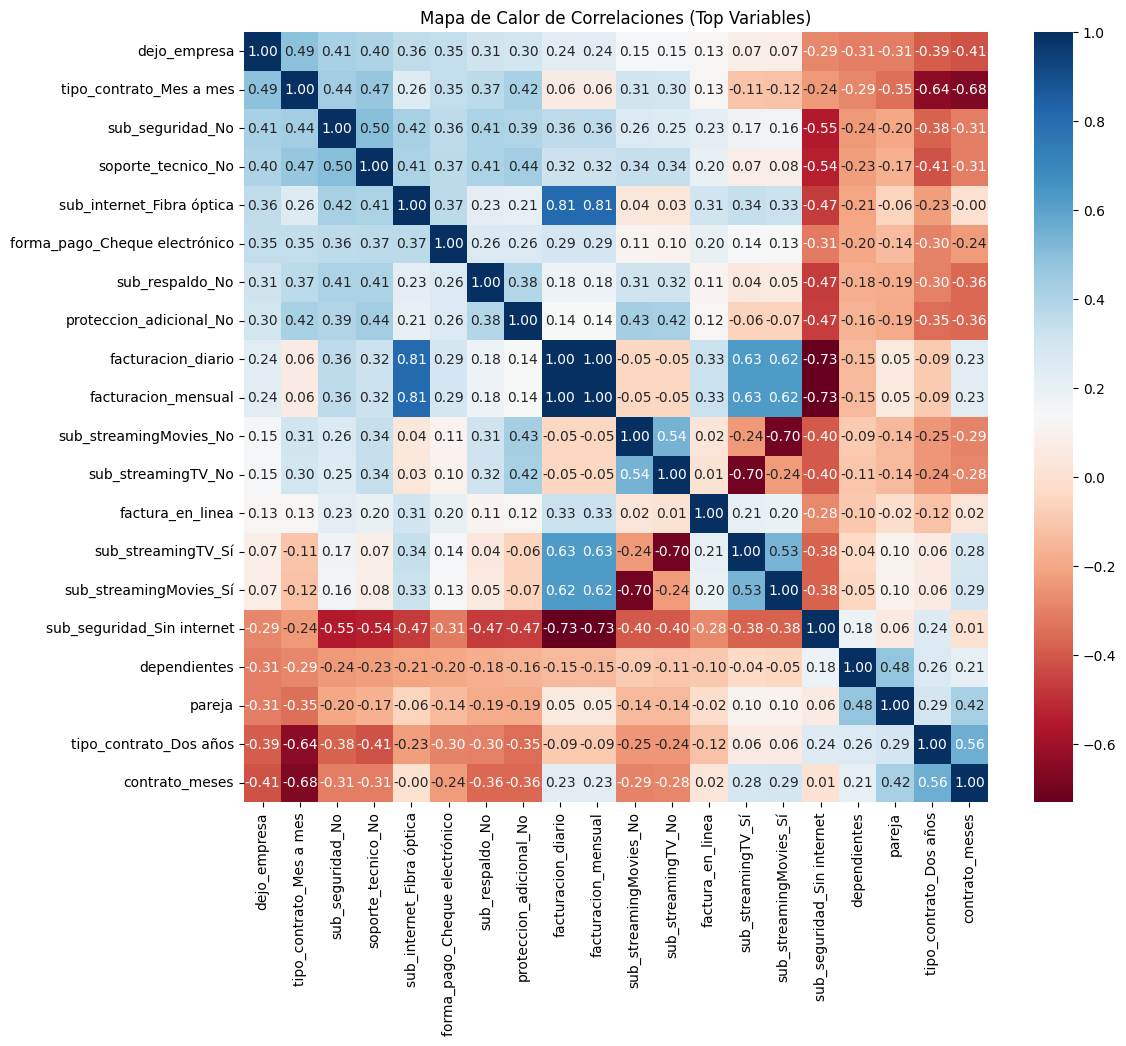

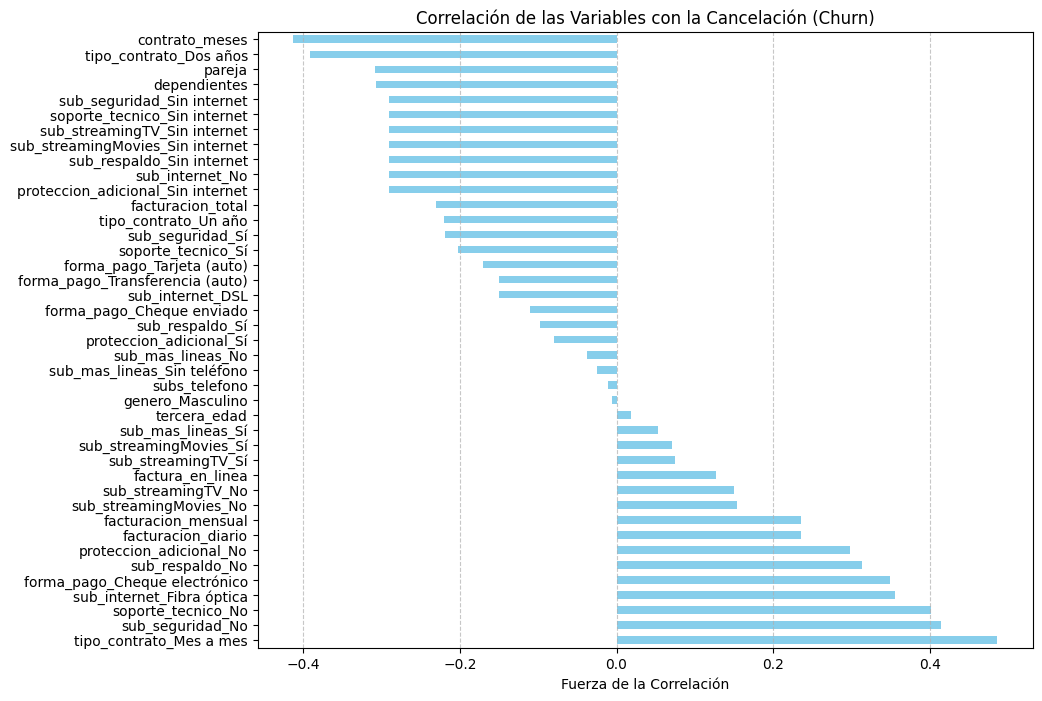

--- Variables con Mayor Correlación Positiva (Aumentan el Churn) ---
dejo_empresa                     1.000000
tipo_contrato_Mes a mes          0.486253
sub_seguridad_No                 0.414408
soporte_tecnico_No               0.401074
sub_internet_Fibra óptica        0.355034
forma_pago_Cheque electrónico    0.349447
sub_respaldo_No                  0.313116
Name: dejo_empresa, dtype: float64

--- Variables con Mayor Correlación Negativa (Reducen el Churn) ---
dependientes             -0.307636
pareja                   -0.308413
tipo_contrato_Dos años   -0.391403
contrato_meses           -0.413348
Name: dejo_empresa, dtype: float64


In [26]:
df_analisis = pd.concat([X_balanceado, y_balanceado], axis=1)

corr_matrix = df_analisis.corr()
correlacion_churn = corr_matrix['dejo_empresa'].sort_values(ascending=False)

plt.figure(figsize=(12, 10))
top_corr_features = correlacion_churn.index[:15].tolist() + correlacion_churn.index[-5:].tolist()
sns.heatmap(df_analisis[top_corr_features].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Mapa de Calor de Correlaciones (Top Variables)')
plt.show()

plt.figure(figsize=(10, 8))
correlacion_churn.drop('dejo_empresa').plot(kind='barh', color='skyblue')
plt.title('Correlación de las Variables con la Cancelación (Churn)')
plt.xlabel('Fuerza de la Correlación')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- Variables con Mayor Correlación Positiva (Aumentan el Churn) ---")
print(correlacion_churn[correlacion_churn > 0.3])

print("\n--- Variables con Mayor Correlación Negativa (Reducen el Churn) ---")
print(correlacion_churn[correlacion_churn < -0.3])

/tmp/ipykernel_220/3269585090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dejo_empresa', y='contrato_meses', data=df, palette='Set2')


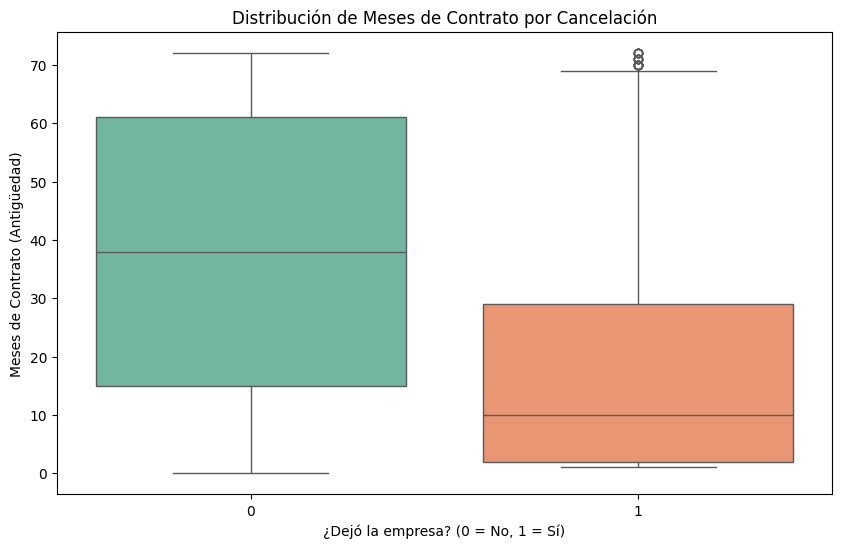

/tmp/ipykernel_220/3269585090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dejo_empresa', y='facturacion_total', data=df, palette='Set1')


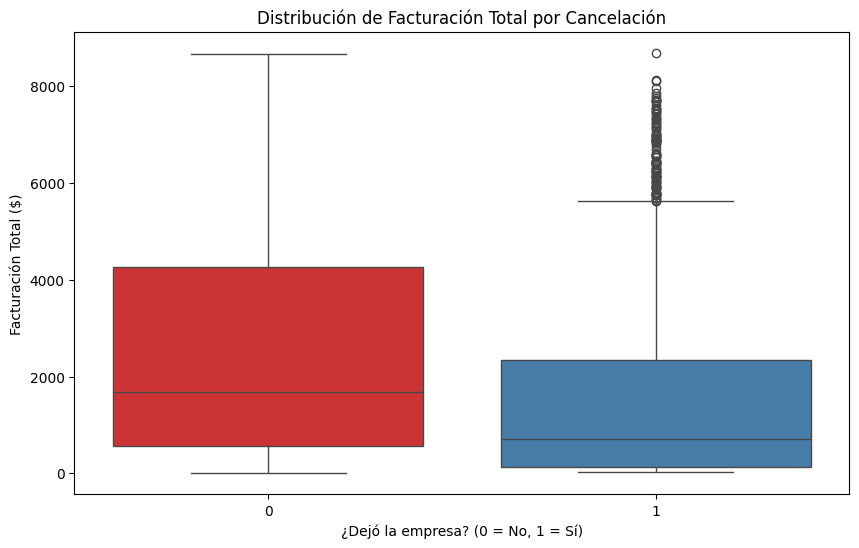

              contrato_meses  facturacion_total
dejo_empresa                                   
0                       38.0           1679.525
1                       10.0            703.550


In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='dejo_empresa', y='contrato_meses', data=df, palette='Set2')
plt.title('Distribución de Meses de Contrato por Cancelación')
plt.xlabel('¿Dejó la empresa? (0 = No, 1 = Sí)')
plt.ylabel('Meses de Contrato (Antigüedad)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='dejo_empresa', y='facturacion_total', data=df, palette='Set1')
plt.title('Distribución de Facturación Total por Cancelación')
plt.xlabel('¿Dejó la empresa? (0 = No, 1 = Sí)')
plt.ylabel('Facturación Total ($)')
plt.show()


print(df.groupby('dejo_empresa')[['contrato_meses', 'facturacion_total']].median())

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final_escalado,
    y_balanceado,
    test_size=0.30,
    random_state=42
)


print("--- RESUMEN DE LA SEPARACIÓN ---")
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Set de Prueba (X_test):        {X_test.shape[0]} muestras")
print(f"Total de características:        {X_train.shape[1]}")

print("\n--- Balance en el set de Entrenamiento ---")
print(y_train.value_counts(normalize=True))

--- RESUMEN DE LA SEPARACIÓN ---
Set de Entrenamiento (X_train): 7243 muestras
Set de Prueba (X_test):        3105 muestras
Total de características:        41

--- Balance en el set de Entrenamiento ---
dejo_empresa
1    0.504901
0    0.495099
Name: proportion, dtype: float64


In [30]:
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train, y_train)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)


¡Modelos creados y entrenados con éxito!


In [32]:
y_pred_log = modelo_logistico.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---
Exactitud (Accuracy): 0.7739
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      1588
           1       0.75      0.81      0.78      1517

    accuracy                           0.77      3105
   macro avg       0.78      0.77      0.77      3105
weighted avg       0.78      0.77      0.77      3105


--- MÉTRICAS: RANDOM FOREST ---
Exactitud (Accuracy): 0.8557
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1588
           1       0.87      0.83      0.85      1517

    accuracy                           0.86      3105
   macro avg       0.86      0.86      0.86      3105
weighted avg       0.86      0.86      0.86      3105



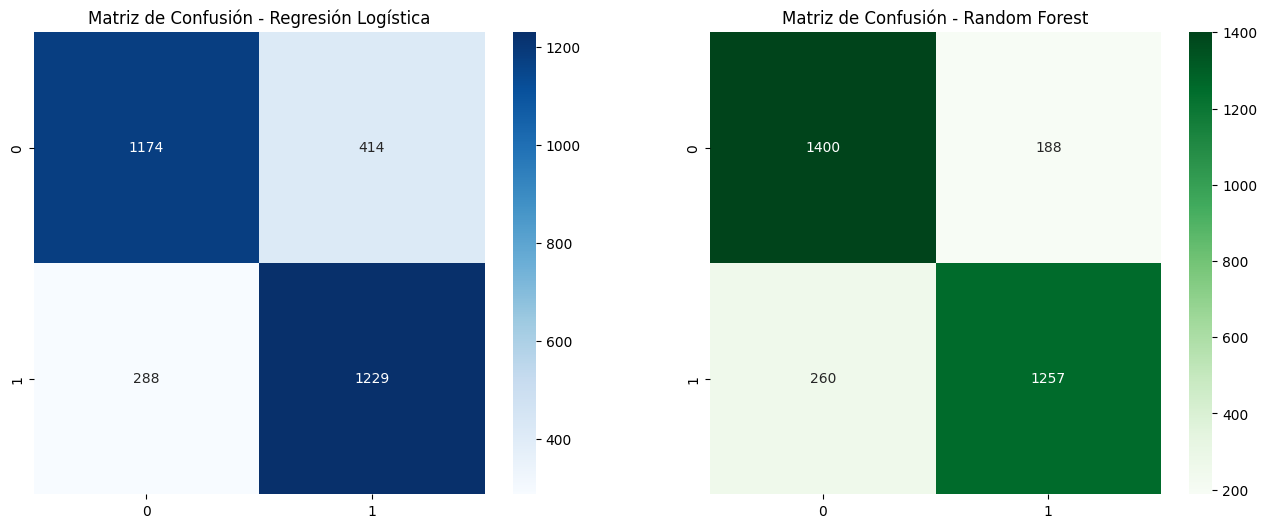

In [33]:
print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

print("\n--- MÉTRICAS: RANDOM FOREST ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

acc_train_log = accuracy_score(y_train, modelo_logistico.predict(X_train))
acc_train_rf = accuracy_score(y_train, modelo_rf.predict(X_train))


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión - Regresión Logística')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz de Confusión - Random Forest')

plt.show()

In [35]:
importancias_log = pd.Series(modelo_logistico.coef_[0], index=X_train.columns).sort_values(ascending=False)

importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)


/tmp/ipykernel_220/2220456184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_log.head(10), y=importancias_log.head(10).index, ax=ax[0], palette='Reds_r')
/tmp/ipykernel_220/2220456184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_rf.head(10), y=importancias_rf.head(10).index, ax=ax[1], palette='Greens_r')


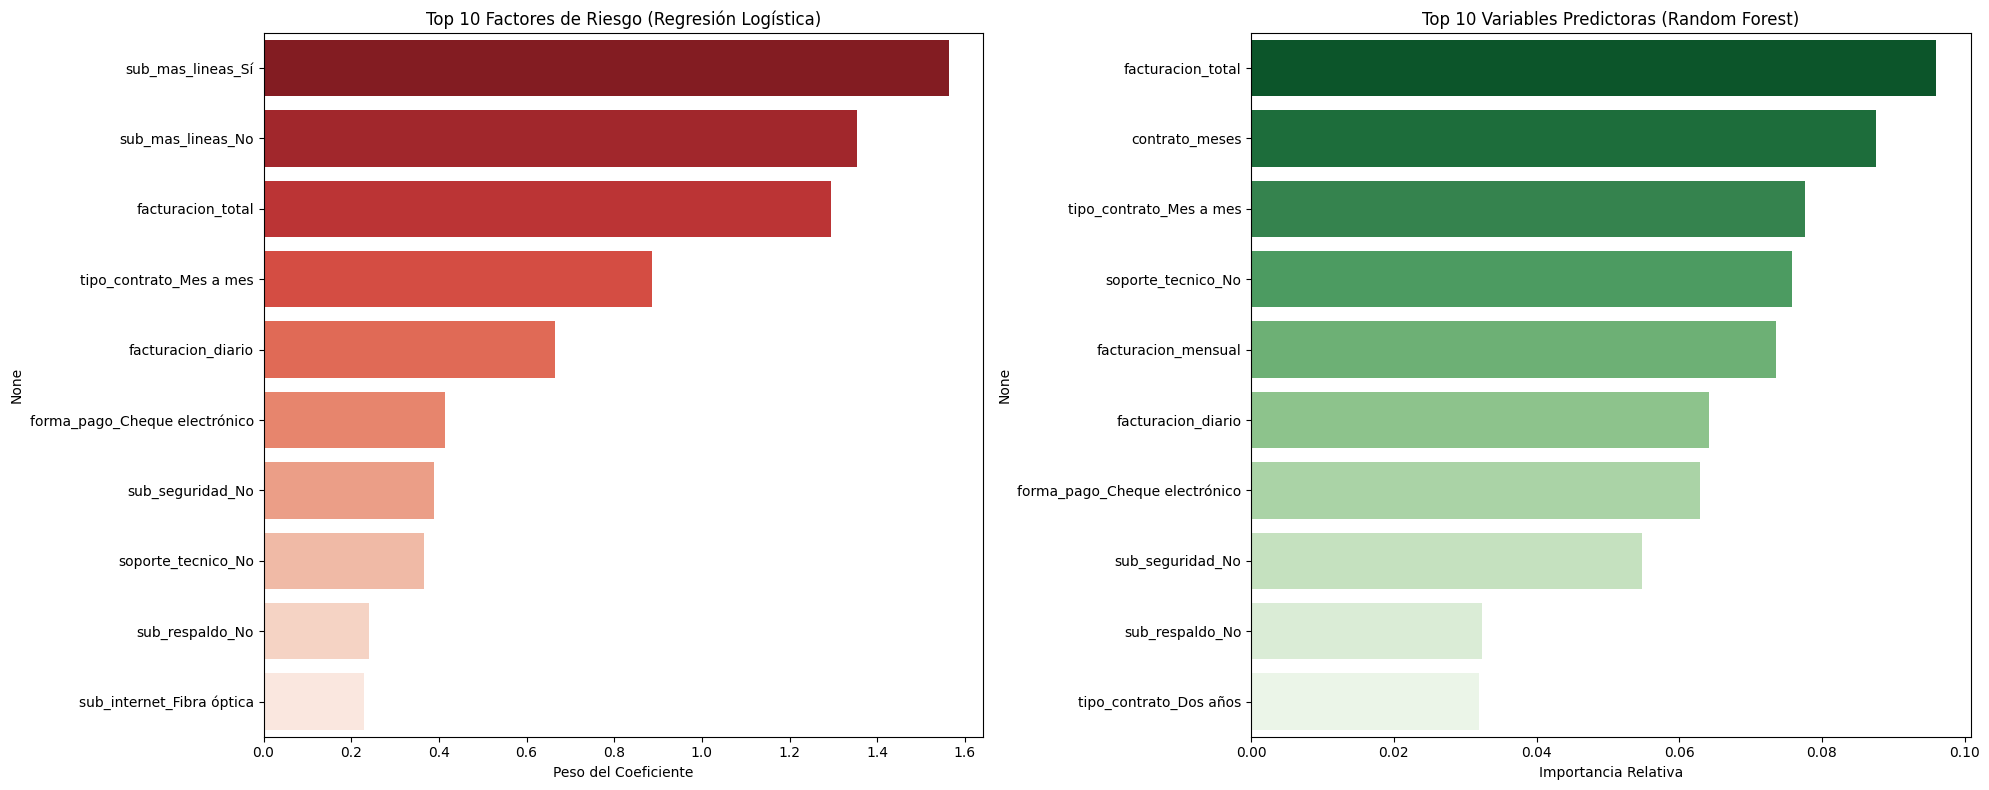

In [36]:
# Gráfico Logística: Los 10 que más empujan a la cancelación
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.barplot(x=importancias_log.head(10), y=importancias_log.head(10).index, ax=ax[0], palette='Reds_r')
ax[0].set_title('Top 10 Factores de Riesgo (Regresión Logística)')
ax[0].set_xlabel('Peso del Coeficiente')

# Gráfico Random Forest: Las 10 variables que más información aportan
sns.barplot(x=importancias_rf.head(10), y=importancias_rf.head(10).index, ax=ax[1], palette='Greens_r')
ax[1].set_title('Top 10 Variables Predictoras (Random Forest)')
ax[1].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

# 📊 Informe Final: Estrategia de Retención Telecom X
**Proyecto:** Challenge Telecom X - Parte 2 (Machine Learning)  

---

## 1. Introducción
El presente informe detalla los hallazgos obtenidos tras el desarrollo de modelos predictivos para identificar la fuga de clientes (*Churn*). El objetivo principal es proporcionar a la gerencia de Telecom X herramientas basadas en datos para reducir la cancelación de servicios y mejorar la rentabilidad.

## 2. Evaluación de Modelos Predictivos
Se entrenaron y compararon dos algoritmos con naturalezas distintas para asegurar la robustez de las predicciones:

* **Regresión Logística:** Modelo basado en probabilidades que permitió entender la dirección del impacto de cada variable. Logró una exactitud del **77.39%**.
* **Random Forest:** Modelo basado en ensambles de árboles de decisión. Fue el modelo con mejor desempeño, alcanzando una **exactitud del 85.57%**.

### Comparativa de Métricas (Clase Churn)
| Modelo | Exactitud | Precisión | Recall (Sensibilidad) | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| Regresión Logística | 77.39% | 75% | 81% | 0.78 |
| **Random Forest** | **85.57%** | **87%** | **83%** | **0.85** |

**Veredicto:** El modelo **Random Forest** es el seleccionado para la implementación, ya que ofrece un equilibrio superior entre la detección de clientes que se van (Recall) y la minimización de falsas alarmas (Precisión).

## 3. Identificación de Factores Críticos
A través del análisis de importancia de variables (*Feature Importance*) y coeficientes, determinamos los detonantes principales de la cancelación:

1.  **Tipo de Contrato (Mes a mes):** Es el factor de riesgo más crítico. La falta de compromiso a largo plazo facilita la salida del cliente.
2.  **Servicio de Fibra Óptica:** Los clientes con fibra óptica tienen una probabilidad de fuga significativamente mayor en comparación con DSL, lo que sugiere una oportunidad de mejora en la calidad o precio de este servicio.
3.  **Falta de Servicios de Valor:** La ausencia de `Soporte Técnico`, `Seguridad Online` y `Respaldo en la Nube` está fuertemente correlacionada con la cancelación.
4.  **Tenencia (Meses de Contrato):** Existe una "zona de peligro" en los primeros **10 meses** de vida del cliente, donde ocurre la mayoría de las bajas.

## 4. Estrategias de Retención Propuestas

Basado en la evidencia de los modelos, se recomiendan las siguientes acciones:

* **🛒 Estrategia de Cross-Selling:** Crear paquetes promocionales que incluyan `Soporte Técnico` y `Seguridad Online` para clientes de Fibra Óptica. Estos servicios actúan como "anclas" que aumentan la lealtad.
* **📅 Migración de Contratos:** Incentivar la transición de contratos mensuales a contratos de 1 o 2 años mediante descuentos progresivos o beneficios en la velocidad de conexión.
* **🛡️ Programa de "Bienvenida Crítica":** Implementar un protocolo de seguimiento intensivo durante los primeros 12 meses del cliente, ofreciendo bonificaciones por lealtad al cumplir el primer semestre.
* **🛠️ Auditoría de Servicio en Fibra:** Realizar un análisis técnico sobre la estabilidad del servicio de fibra óptica para descartar que la fuga sea causada por fallas recurrentes en esa tecnología.

## 5. Conclusión General
La implementación del modelo **Random Forest** permitirá a Telecom X actuar de manera proactiva. Al identificar a los clientes en riesgo con un **85% de confianza**, la empresa puede pasar de una postura reactiva a una estrategia de retención dirigida, optimizando el uso de recursos y protegiendo la base de ingresos mensual.